<a href="https://colab.research.google.com/github/nieko1/Arctic-Hydrology-Assignment-/blob/main/Colab3_SpatialAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab 3: Where could Samoylov-like hydrological processes occur?

In the previous exercises, we used Samoylov Island to identify several controls on polygonal-tundra hydrology:

- **permafrost**, which restricts deep drainage;
- **active-layer thickness**, which controls the depth of seasonally available subsurface flow paths;
- **ice-wedge polygon terrain**, which creates strong microtopographic controls on storage and connectivity;
- **surface water and wetland conditions**, which indicate landscape storage;
- **low topographic gradients**, which favour storage and slow drainage;
- **climate**, which controls precipitation, evapotranspiration, snowmelt, and seasonal thaw.

We now move from the local scale to the pan-Arctic scale.

The **ARCADE catchment database** [(Speetjens et al., 2023)](https://doi.org/10.5194/essd-15-541-2023) contains environmental information for tens of thousands of Arctic catchments. We will use these data to identify catchments where the environmental setting is similar enough to Samoylov that comparable hydrological processes may plausibly occur.

## Main question

> **Where in the Arctic are the environmental conditions favourable for Samoylov-like polygonal-tundra hydrology?**

We will not assume that environmental similarity proves that the same hydrological processes occur.

Instead, the spatial analysis will be used to generate **testable hypotheses** about where these processes are most likely to operate.

## Strategy

We will separate the analysis into two steps:

### 1. Domain of applicability

First, we identify catchments where the basic environmental conditions required by our process model are present.

For example, a catchment with almost no permafrost or no mapped ice-wedge polygons would not be a meaningful analogue of Samoylov, even if its climate were similar.

### 2. Environmental similarity

Within this domain, we compare catchments using variables that describe how similar their environmental setting is to Samoylov.

Candidate variables include:

- mean catchment slope;
- active-layer thickness;
- mean annual air temperature;
- annual precipitation;
- surface-water fraction;
- ice-wedge polygon fraction.

Later, we will examine whether differences in **low-centred and high-centred polygon abundance** change this interpretation.

## From spatial analysis to field-campaign design

The purpose of the spatial analysis is not only to identify environmental analogues of Samoylov.

The results will also be used to design a **field campaign** that can test whether the inferred hydrological processes are actually transferable to other Arctic landscapes.

The exercises in this notebook will therefore help you identify:

- where Samoylov-like conditions are most likely to occur;
- where important environmental controls differ;
- which catchments would provide useful contrasts;
- which measurements would be needed to test whether runoff generation, thaw-related connectivity, and associated solute transport behave as expected.

By the end of the exercise, you will use the spatial analysis to select a small number of candidate field sites and formulate a sampling strategy that can **test or falsify** the transferability of the Samoylov process model.

### Final objective

The spatial analysis should provide the evidence needed to answer:

> **Where should we measure, what should we measure, and what result would show that the Samoylov process model does not apply?**

### ASSUMPTION

We assume that catchment-scale environmental attributes can be used as spatial proxies for some of the controls identified at Samoylov.

These variables do not resolve polygon-scale flow paths directly. A catchment identified as a strong analogue should therefore be interpreted as a **candidate location for similar processes**, not as evidence that those processes actually occur.

## 1. Choosing spatial variables

The first step is to decide which ARCADE variables represent the environmental controls identified at Samoylov.

Not all variables should be treated in the same way.

Some describe conditions that are probably **necessary** for the Samoylov process model to be relevant. These can be used to define a **domain of applicability**.

Other variables describe how similar a catchment is to Samoylov within that domain.

We will therefore distinguish between:

### Domain-of-applicability variables

These determine whether a catchment should be considered at all.

Candidate variables include:

- **permafrost fraction**: the Samoylov process model depends on shallow, ice-rich permafrost restricting deep drainage;
- **ice-wedge polygon fraction**: polygon microtopography is central to the storage and connectivity processes examined in the previous exercises;
- **ice-covered fraction**: heavily glacierized catchments represent a fundamentally different hydrological system.

### Similarity variables

Within the applicable domain, we will compare catchments using environmental characteristics such as:

- mean slope;
- active-layer thickness;
- mean annual air temperature;
- annual precipitation;
- surface-water fraction;
- ice-wedge polygon fraction.

These variables represent different parts of the conceptual model:

| Process control | ARCADE proxy |
|---|---|
| Permafrost control on drainage | Permafrost fraction |
| Seasonal subsurface flow depth | Active-layer thickness |
| Polygon microtopography | Ice-wedge polygon fraction |
| Landscape water storage | Surface-water fraction |
| Topographic drainage potential | Mean slope |
| Thermal forcing | Mean annual air temperature |
| Water input | Annual precipitation |

Later, we will add information on **high-centred and low-centred polygon abundance** to examine whether polygon state changes the interpretation of environmental similarity.

### ASSUMPTION

Catchment-average variables cannot resolve polygon-scale geometry directly.

For example, a high ice-wedge polygon fraction indicates that polygonal terrain is abundant, but it does not tell us whether individual rims are intact, degraded, or hydrologically connected.

The spatial variables are therefore used as **process proxies**, and their limitations should be considered when selecting field sites.

## 2. Load and inspect the ARCADE catchment data

We first load the ARCADE catchment dataset and inspect the available attributes.

Before applying any filters or similarity calculations, we need to confirm:

- which variables are available;
- their units;
- whether they contain missing values;
- whether their ranges are physically plausible.

This step is important because the spatial analysis depends entirely on how these variables are defined.

### ASSUMPTION

We treat the ARCADE catchment attributes as catchment-average environmental descriptors.

They therefore represent broad landscape conditions rather than local polygon-scale variability.

In [ ]:
# ------------------------------------------------------------
# Load ARCADE GeoParquet from GitHub
# ------------------------------------------------------------

# Import packages
import geopandas as gpd
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import requests


# ------------------------------------------------------------
# Download course data
# ------------------------------------------------------------

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)


files = {"arcade_hydrology_iwp.parquet":
    "https://raw.githubusercontent.com/"
    "nieko1/Arctic-Hydrology-Assignment-/main/data/"
    "arcade_hydrology_iwp.parquet"
}

for filename, url in files.items():
    path = DATA_DIR / filename

    if not path.exists():
        print(f"Downloading {filename}...")
        response = requests.get(url)
        response.raise_for_status()
        path.write_bytes(response.content)

print("Course data ready.")

arcade_path = DATA_DIR / "arcade_hydrology_iwp.parquet"
arcade = gpd.read_parquet(arcade_path)

print(f"Number of catchments: {len(arcade):,}")
print(f"CRS: {arcade.crs}")
arcade.head()


Course data ready.
Number of catchments: 47,054
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "WGS 84 / NSIDC EASE-Grid 2.0 North", "base_crs": {"type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north",

,catchment_id,name,continent,latitude,longitude,area_km2,slope_deg,elevation_m,twi,permafrost_frac,active_layer_m,iwp_frac,surface_water_frac,ice_frac,maat_c,precip_mm_yr,max_snowmelt_mm_day,iwp_coverage_witharanamean,geometry,et_mm_yr
0,1,None,Eurasia,66.503,179.934,10.117,10.733561,359.198517,4.324897,0.933,1.247561,0.000,0.0000,0.0,-8.836629,551.905226,7.923786,0.000000,"POLYGON ((2515.091 2607525.02, 2830.091 260725...",142.656118
1,2,None,Eurasia,68.913,179.787,32.902,4.997916,53.524197,3.307838,1.000,1.082810,0.276,0.0000,0.0,-9.622999,518.682381,7.147688,0.000000,"POLYGON ((12865.091 2343825.019, 13180.091 234...",155.778400
2,3,None,Eurasia,68.938,179.777,18.104,5.259800,61.921070,3.563065,1.000,1.039666,0.136,0.0001,0.0,-9.586912,521.988710,7.031647,0.000000,"MULTIPOLYGON (((8995.091 2340675.019, 9760.091...",158.985514
3,1059,None,Eurasia,71.640,133.081,2.624,0.979538,10.213270,7.520925,0.999,0.518673,0.976,0.0000,0.0,-11.998328,290.309540,NaN,0.194461,"POLYGON ((1490490 1395270, 1491390 1395090, 14...",NaN
4,4,None,Eurasia,68.943,179.873,8.060,1.348255,16.162729,5.456685,1.000,0.966924,0.755,0.0000,0.0,-9.582159,522.424190,NaN,0.000000,"POLYGON ((5575.091 2340135.019, 6520.091 23393...",NaN


## 3. Inspect the ARCADE catchment attributes

Before selecting environmental analogues, we first inspect the variables available for each catchment.

We are interested in variables that represent the hydrological controls identified at Samoylov:

- permafrost extent;
- active-layer thickness;
- ice-wedge polygon abundance;
- surface-water abundance;
- topographic gradient;
- temperature;
- precipitation;
- snowmelt.

We will first check whether these variables are present and examine their ranges.

In [ ]:
# ------------------------------------------------------------
# Variables relevant to the Samoylov process model
# ------------------------------------------------------------

candidate_variables = [
    "area_km2",
    "slope_deg",
    "twi",
    "permafrost_frac",
    "active_layer_m",
    "iwp_frac",
    "surface_water_frac",
    "ice_frac",
    "maat_c",
    "precip_mm_yr",
    "max_snowmelt_mm_day",
    "et_mm_yr"
]


# Which variables are actually present?

available_variables = [
    var for var in candidate_variables
    if var in arcade.columns
]

missing_variables = [
    var for var in candidate_variables
    if var not in arcade.columns
]


print("Available variables:")
for var in available_variables:
    print("  ", var)

if missing_variables:
    print("\nVariables not found:")
    for var in missing_variables:
        print("  ", var)


# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

summary = arcade[available_variables].describe().T[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

summary["missing"] = (
    len(arcade)
    - arcade[available_variables].count()
)

summary.round(2)

Available variables:
   area_km2
   slope_deg
   twi
   permafrost_frac
   active_layer_m
   iwp_frac
   surface_water_frac
   ice_frac
   maat_c
   precip_mm_yr
   max_snowmelt_mm_day
   et_mm_yr


,count,mean,std,min,25%,50%,75%,max,missing
area_km2,47054.0,527.55,25756.27,1.00,5.53,11.87,35.06,3117158.52,0
slope_deg,47043.0,5.57,6.28,0.01,0.76,2.91,8.62,38.64,11
twi,47054.0,5.05,1.74,0.34,3.69,4.76,6.23,12.86,0
permafrost_frac,47053.0,0.64,0.42,0.00,0.13,0.92,1.00,1.00,1
active_layer_m,39202.0,0.93,0.45,0.28,0.66,0.86,1.07,5.17,7852
iwp_frac,47054.0,0.37,0.43,0.00,0.00,0.06,0.90,1.00,0
surface_water_frac,47054.0,0.06,0.09,0.00,0.00,0.02,0.08,0.99,0
ice_frac,47054.0,0.11,0.27,0.00,0.00,0.00,0.00,1.00,0
maat_c,47035.0,-8.74,6.15,-25.35,-13.35,-9.80,-5.11,8.31,19
precip_mm_yr,47035.0,585.99,463.25,94.08,289.45,418.64,662.26,3099.99,19


### Questions

1. Which variables have substantial missing data?
2. Are there variables with extreme values that should be inspected before using them?
3. Which variables describe conditions that seem **necessary** for Samoylov-like polygonal-tundra hydrology?
4. Which variables describe a **gradient of similarity** rather than a strict requirement?

In the next step, we will use this distinction to define a **domain of applicability** before calculating environmental similarity.

## 4. Define the domain of applicability

Before asking which catchments are most similar to Samoylov, we first remove catchments where the basic process model is unlikely to apply.

The hydrological behaviour examined at Samoylov depends on three broad landscape conditions:

1. **permafrost must be widespread**, because frozen ground restricts deep drainage and creates a shallow seasonally thawed flow domain;
2. **ice-wedge polygon terrain must be present**, because polygon microtopography controls storage and lateral connectivity;
3. **glacier ice should not dominate the catchment**, because strongly glacierized catchments represent a different hydrological system.

We therefore use these variables as **domain filters**, rather than as measures of similarity.

### Initial thresholds

For this exercise, we define the process domain as:

$$
f_{\mathrm{permafrost}} \geq 0.80
$$

$$
f_{\mathrm{IWP}} \geq 0.10
$$

$$
f_{\mathrm{ice}} \leq 0.10
$$

These thresholds are deliberately broad. They are intended to exclude clearly unsuitable catchments while retaining environmental variation within the polygonal-permafrost domain.

### ASSUMPTION

The thresholds are analytical choices, not known physical boundaries.

A catchment with 79% permafrost is not fundamentally different from one with 80% permafrost. We use thresholds only to define a practical domain in which comparison with Samoylov is meaningful.

Active-layer thickness is **not** used as a hard filter because it contains substantial missing data and because active-layer thickness is better interpreted as a gradient of hydrological similarity.

In [ ]:
# ------------------------------------------------------------
# Define the Samoylov-like process domain
# ------------------------------------------------------------

PERMAFROST_MIN = 0.80
IWP_MIN = 0.10
ICE_MAX = 0.10


domain = arcade[
    (arcade["permafrost_frac"] >= PERMAFROST_MIN)
    & (arcade["iwp_frac"] >= IWP_MIN)
    & (arcade["ice_frac"] <= ICE_MAX)
].copy()


print(f"All ARCADE catchments:     {len(arcade):,}")
print(f"Catchments in domain:      {len(domain):,}")
print(
    f"Fraction retained:         "
    f"{len(domain) / len(arcade):.1%}"
)

All ARCADE catchments:     47,054
Catchments in domain:      20,146
Fraction retained:         42.8%


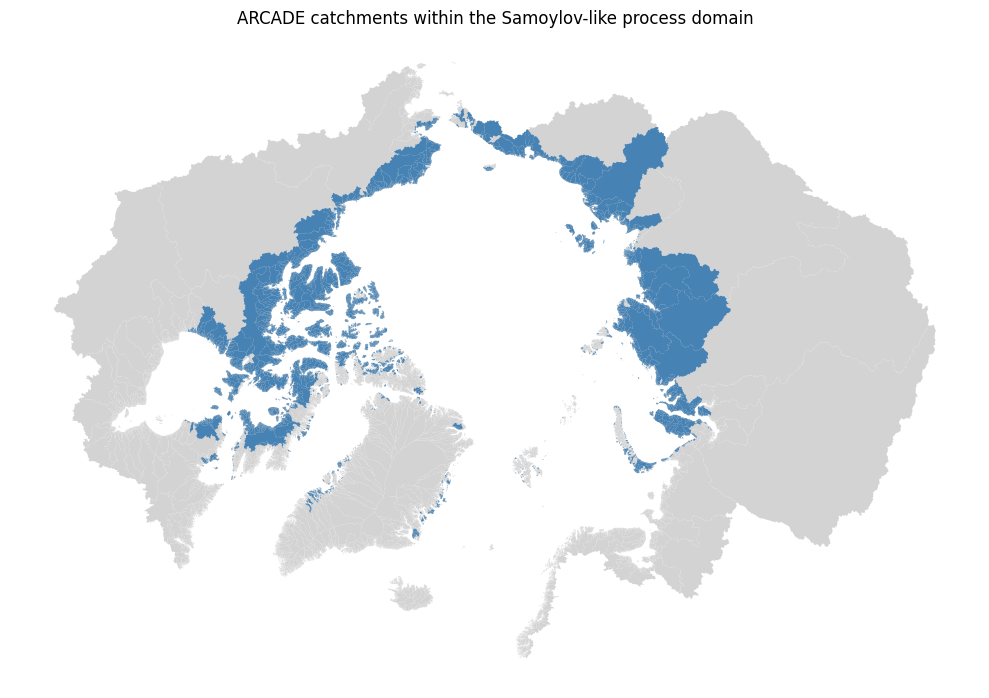

In [ ]:
# ------------------------------------------------------------
# Map all ARCADE catchments and the retained process domain
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

# All ARCADE catchments
arcade.plot(
    ax=ax,
    facecolor="lightgrey",
    edgecolor="none"
)

# Catchments retained in the process domain
domain.plot(
    ax=ax,
    facecolor="steelblue",
    edgecolor="none"
)

ax.set_title(
    "ARCADE catchments within the Samoylov-like process domain"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

### ASSUMPTION

Catchments shown in blue are not yet considered **Samoylov analogues**.

They only satisfy the broad environmental conditions required for the process model to remain plausible.

The next step is to compare these retained catchments with Samoylov using continuous environmental variables such as slope, active-layer thickness, climate, and surface-water fraction.

## 6. Define the Samoylov environmental reference

We now compare the retained catchments with Samoylov using continuous environmental variables.

To keep the comparison defensible, we only use variables for which we have a clear Samoylov reference value.

For this exercise, we use:

| Variable | Samoylov reference | Hydrological relevance |
|---|---:|---|
| Mean slope | 0.10° | Controls gravitational drainage potential |
| Active-layer thickness | 0.40 m | Controls the depth of seasonally available subsurface flow paths |
| Mean annual air temperature | −13.5 °C | Represents the thermal regime |
| Annual precipitation | 323 mm yr$^{-1}$ | Represents long-term water input |

Samoylov is extremely low-gradient, with catchment slopes generally below about 0.2%. The active layer typically reaches approximately 0.3–0.5 m by late summer, while the regional climatological mean annual air temperature and precipitation are approximately −13.5 °C and 323 mm yr$^{-1}$, respectively.

### Why not use every ARCADE variable?

Some variables have already been used to define the process domain.

For example, permafrost and ice-wedge polygon fractions determine whether the Samoylov process model is broadly applicable, but we do not need to force a candidate catchment to have exactly the same fraction as Samoylov.

Other potentially useful variables do not yet have a sufficiently well-constrained Samoylov reference value.

The similarity calculation is therefore intentionally conservative.

### ASSUMPTION

Each similarity variable is treated as an independent environmental control.

In reality, climate, thaw depth, topography, and surface conditions are partly correlated.

In [ ]:
# ------------------------------------------------------------
# Samoylov reference values
# ------------------------------------------------------------

samoylov = {
    "slope_deg": 0.10,
    "active_layer_m": 0.40,
    "maat_c": -13.5,
    "precip_mm_yr": 323.0,
    "et_mm_yr": 178.0
}

similarity_variables = list(samoylov.keys())


# ------------------------------------------------------------
# Keep catchments with complete data for these variables
# ------------------------------------------------------------

similarity_data = domain.dropna(
    subset=similarity_variables
).copy()


print(f"Catchments in process domain:      {len(domain):,}")
print(f"Catchments with complete data:     {len(similarity_data):,}")
print(
    f"Removed because of missing data:   "
    f"{len(domain) - len(similarity_data):,}"
)

Catchments in process domain:      20,146
Catchments with complete data:     17,269
Removed because of missing data:   2,877


### Question

Before calculating a similarity score:

> Which of these four variables do you expect to most strongly distinguish Samoylov from other polygonal-permafrost catchments?

Explain your prediction in one or two sentences.

## 7. Calculate environmental similarity to Samoylov

The environmental variables have different units and very different distributions. Before combining them, we therefore express each variable relative to its variability across the process domain.

Because several ARCADE variables are strongly skewed, we use the median and interquartile range (IQR) rather than the mean and standard deviation:

$$
x'_{ij} =
\frac{x_{ij}-\mathrm{median}_j}
{\mathrm{IQR}_j}
$$

The same transformation is applied to the Samoylov reference values.
where:

- $x_{ij}$ = value of variable $j$ for catchment $i$
- $\mu_j$ = mean of variable $j$ across the retained catchments
- $\sigma_j$ = standard deviation of variable $j$

We apply the same transformation to the Samoylov reference values.

Environmental distance from Samoylov is then calculated using Euclidean distance in standardized environmental space:

$$
D_i =
\sqrt{
\sum_j
\left(
z_{ij}-z_{\mathrm{Samoylov},j}
\right)^2
}
$$

A small value of $D$ indicates a catchment with environmental conditions similar to Samoylov.

For easier interpretation, we also convert distance to a similarity score:

$$
S_i = \frac{1}{1+D_i}
$$

so that:

- $S \rightarrow 1$ indicates high environmental similarity;
- smaller values indicate increasingly different environmental conditions.

### ASSUMPTION

All four variables are given equal weight in the similarity calculation.

This does **not** mean that they are equally important hydrologically. Equal weighting is used because we do not yet have independent evidence for assigning different process weights.

In [ ]:
# ------------------------------------------------------------
# Robustly scale the environmental variables
# ------------------------------------------------------------

similarity_data = similarity_data.copy()

median = similarity_data[similarity_variables].median()

iqr = (
    similarity_data[similarity_variables].quantile(0.75)
    - similarity_data[similarity_variables].quantile(0.25)
)

# Check that no variable has zero variability
if (iqr == 0).any():
    raise ValueError(
        "At least one similarity variable has an IQR of zero."
    )


# Scale ARCADE catchments
for var in similarity_variables:
    similarity_data[f"{var}_scaled"] = (
        similarity_data[var] - median[var]
    ) / iqr[var]


# Scale Samoylov using exactly the same transformation
samoylov_scaled = {
    var: (samoylov[var] - median[var]) / iqr[var]
    for var in similarity_variables
}


# ------------------------------------------------------------
# Environmental distance from Samoylov
# ------------------------------------------------------------

squared_differences = np.column_stack([
    (
        similarity_data[f"{var}_scaled"]
        - samoylov_scaled[var]
    ) ** 2
    for var in similarity_variables
])

similarity_data["environmental_distance"] = np.sqrt(
    squared_differences.mean(axis=1)
)


# ------------------------------------------------------------
# Convert distance to an intuitive similarity index
# ------------------------------------------------------------

similarity_data["similarity_score"] = (
    1 / (1 + similarity_data["environmental_distance"])
)


# ------------------------------------------------------------
# Inspect strongest environmental analogues
# ------------------------------------------------------------

top_analogues = similarity_data.nsmallest(
    10,
    "environmental_distance"
)

columns_to_show = (
    similarity_variables
    + ["environmental_distance", "similarity_score"]
)

top_analogues[columns_to_show].round(3)

,slope_deg,active_layer_m,maat_c,precip_mm_yr,et_mm_yr,environmental_distance,similarity_score
5142,0.114,0.543,-12.889,315.560,175.204,0.196,0.836
1579,0.050,0.472,-12.401,316.635,159.942,0.206,0.829
821,0.264,0.512,-12.642,283.554,180.184,0.209,0.827
812,0.464,0.494,-12.663,281.078,180.184,0.212,0.825
1015,0.044,0.515,-12.157,294.906,180.553,0.219,0.820
905,0.455,0.445,-12.522,274.206,167.623,0.219,0.820
933,0.099,0.490,-12.402,280.438,166.838,0.223,0.818
928,0.423,0.461,-12.410,272.578,170.094,0.225,0.816
1667,0.054,0.531,-13.408,278.854,167.899,0.229,0.814
4212,0.084,0.513,-12.298,279.327,179.746,0.230,0.813


### Question

Inspect several catchments with low environmental distance.

Are they close to Samoylov across **all four variables**, or can a relatively large difference in one variable be compensated by similarity in the others?

What does this tell you about interpreting a single multivariate distance value?

## 8. Where does the environmental setting resemble Samoylov?

We now map environmental distance across the complete process domain.

The purpose is to identify **spatial gradients and clusters of environmental similarity**, rather than to define a fixed number of “best” catchments.

Remember that the map only includes catchments with complete observations for all four similarity variables. Areas with missing active-layer data are therefore absent from this comparison.

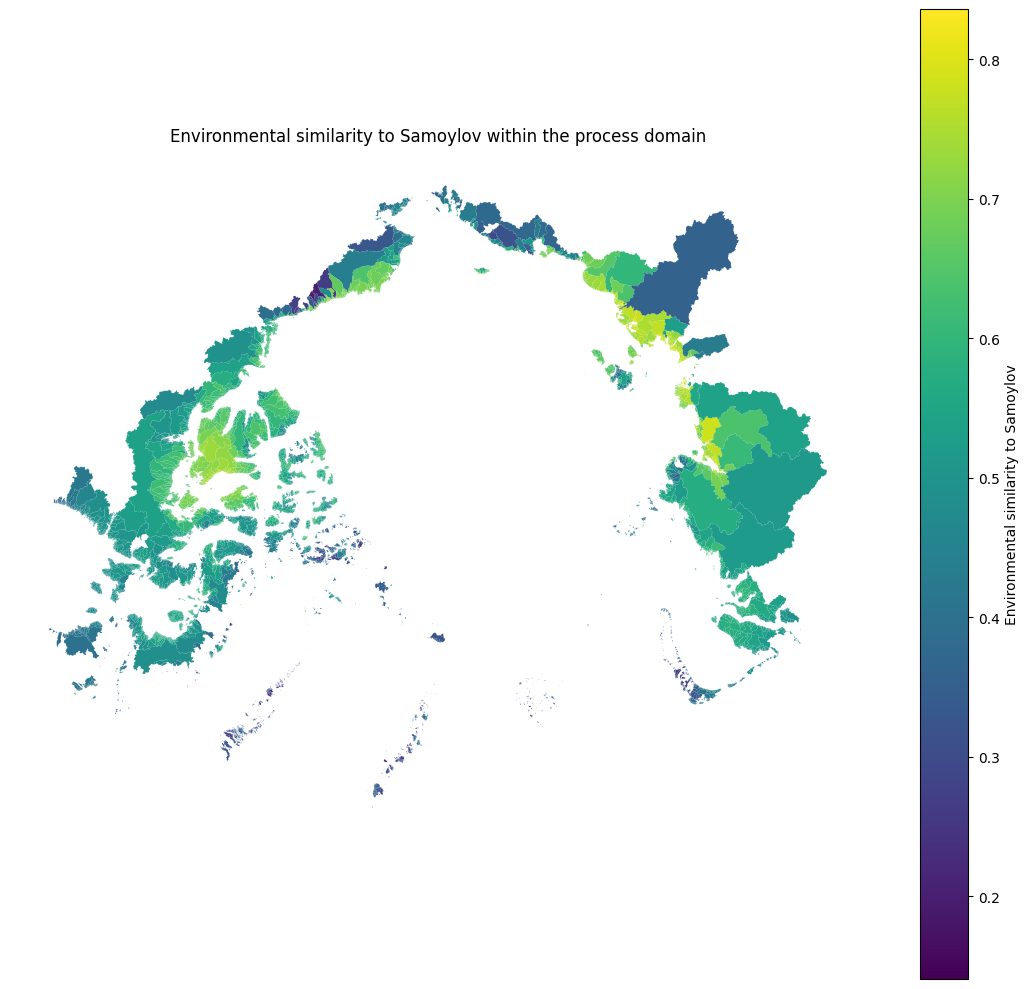

In [ ]:
# ------------------------------------------------------------
# Map environmental similarity to Samoylov
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 10))

similarity_data.plot(
    ax=ax,
    column="similarity_score",
    legend=True,
    edgecolor="none",
    legend_kwds={
        "label": "Environmental similarity to Samoylov"
    }
)

ax.set_title(
    "Environmental similarity to Samoylov within the process domain"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
# Where does each catchment fall within the domain-wide
# distribution of environmental distance?

similarity_data["similarity_percentile"] = (
    similarity_data["similarity_score"]
    .rank(pct=True)
)

print(
    "Environmental similarity thresholds:"
)

for p in [0.01, 0.05, 0.10, 0.25]:
    threshold = similarity_data[
        "similarity_score"
    ].quantile(p)

    print(
        f"Most similar {p:.0%}: D <= {threshold:.2f}"
    )

Environmental similarity thresholds:
Most similar 1%: D <= 0.25
Most similar 5%: D <= 0.32
Most similar 10%: D <= 0.37
Most similar 25%: D <= 0.46


### Questions

1. Where are the main geographic regions containing catchments with low environmental distance from Samoylov?

2. Do those regions form a continuous environmental domain, or are similar conditions found in geographically separate parts of the Arctic?

3. Which environmental variable appears to limit similarity most strongly in different regions? (Hint: you can play around with the parameters to run a first-order sensitivity test)

The next step is to ask whether **polygon morphology** changes this picture. In particular, catchments that are similar in climate, topography, and active-layer thickness may nevertheless differ substantially in the abundance of low-centred and high-centred polygons.

## 9. From environmental similarity to a polygon-transition experiment

Environmental similarity tells us where the broad climatic, topographic, and permafrost setting resembles Samoylov.

It does not tell us the present-day distribution of low-centred and high-centred polygons.

But, we can use the information to run back-of-the-envelope calculations to form hypotheses:

> **If the same change from low-centred toward high-centred polygon conditions occurred across similar Arctic catchments, could that possibly significantly impact the lateral component of the Arctic carbon budget (i.e., how much carbon is moved from land to sea)?**

To explore this, we combine three pieces of information:

1. the fraction of each catchment occupied by mapped ice-wedge polygon terrain;
2. hypothetical proportions of low-centred and high-centred polygons within that terrain;
3. assumed differences in runoff and carbon export between the two polygon states.

For each catchment, ARCADE provides the mapped ice-wedge polygon fraction:

$$
f_{\mathrm{IWP}}
$$

We then assume that some fraction of this polygonal terrain consists of low-centred polygons:

$$
p_{\mathrm{LCP}}
$$

so that:

$$
f_{\mathrm{LCP}}
=
f_{\mathrm{IWP}}p_{\mathrm{LCP}}
$$

and:

$$
f_{\mathrm{HCP}}
=
f_{\mathrm{IWP}}(1-p_{\mathrm{LCP}})
$$

Because we do not know the true LCP/HCP distribution, we explore several possible starting conditions rather than selecting one value.

| Scenario | LCP within IWP | HCP within IWP |
|---|---:|---:|
| LCP-dominated | 0.75 | 0.25 |
| Mixed | 0.50 | 0.50 |
| HCP-dominated | 0.25 | 0.75 |

We then impose a hypothetical transition in which part of the existing LCP area changes toward an HCP state:

$$
f_{\mathrm{LCP,future}}
=
f_{\mathrm{LCP,initial}}(1-c)
$$

$$
f_{\mathrm{HCP,future}}
=
f_{\mathrm{HCP,initial}}
+
c\,f_{\mathrm{LCP,initial}}
$$

where $c$ is the fraction of existing LCP area converted.

We will use this change in landscape composition to estimate two possible consequences:

$$
\boxed{\mathrm{LCP}\rightarrow\mathrm{HCP}
\rightarrow
\Delta Q}
$$

and subsequently:

$$
\boxed{
\Delta Q
\;+\;
\Delta C_{\mathrm{DOC}}
\rightarrow
\Delta F_{\mathrm{DOC}}
}
$$

where:

- $Q$ = annual runoff;
- $C_{\mathrm{DOC}}$ = dissolved organic carbon concentration;
- $F_{\mathrm{DOC}}$ = annual lateral DOC export.

The purpose is not to predict the future carbon export of individual catchments.

Instead, we ask whether plausible changes in polygon morphology could produce effects large enough to matter at the catchment scale, and whether those effects could become important when aggregated across large areas of Arctic polygonal terrain.

### ASSUMPTIONS

The LCP and HCP fractions used here are hypothetical scenarios, not mapped observations.

The LCP-to-HCP transition is also treated as a simple structural change. Real polygon degradation may involve intermediate states, drainage-network development, thermokarst, changes in vegetation, active-layer thickness, and changes in soil properties.

The resulting calculations should therefore be interpreted as **sensitivity experiments used to generate hypotheses**, rather than as predictions.

### Question

Before running the calculation:

> Which catchments would you expect to show the largest response to the same assumed LCP-to-HCP transition?

Consider both the abundance of ice-wedge polygon terrain and the environmental similarity to Samoylov.

## 10. Construct hypothetical LCP–HCP distributions

ARCADE provides the fraction of each catchment occupied by ice-wedge polygon terrain:

$$
f_{\mathrm{IWP}}
$$

but does not distinguish low-centred from high-centred polygons.

We therefore describe polygon morphology using scenarios.

For a given assumed proportion of LCP within the mapped IWP area,

$$
p_{\mathrm{LCP}}
$$

the catchment fractions occupied by LCP and HCP are:

$$
f_{\mathrm{LCP}}
=
f_{\mathrm{IWP}}p_{\mathrm{LCP}}
$$

and

$$
f_{\mathrm{HCP}}
=
f_{\mathrm{IWP}}(1-p_{\mathrm{LCP}})
$$

We consider three possible starting states:

| Scenario | LCP within IWP | HCP within IWP |
|---|---:|---:|
| LCP-dominated | 0.75 | 0.25 |
| Mixed | 0.50 | 0.50 |
| HCP-dominated | 0.25 | 0.75 |

We then impose the same hypothetical disturbance in every catchment: **50% of the existing LCP area transitions to HCP**.

This does not represent a forecast. It is a controlled sensitivity experiment that allows us to compare the consequences of the same structural change across different environmental settings.

In [ ]:
# ------------------------------------------------------------
# Hypothetical LCP/HCP scenarios
# ------------------------------------------------------------
import pandas as pd
polygon_scenarios = {
    "LCP-dominated": 0.75,
    "Mixed": 0.50,
    "HCP-dominated": 0.25,
}

# Fraction of existing LCP assumed to transition to HCP
conversion_fraction = 0.50

scenario_results = []

for scenario_name, lcp_share in polygon_scenarios.items():

    result = similarity_data.copy()

    # Initial fractions of the WHOLE catchment
    result["lcp_frac_initial"] = (
        result["iwp_frac"] * lcp_share
    )

    result["hcp_frac_initial"] = (
        result["iwp_frac"] * (1 - lcp_share)
    )

    # Fraction of the whole catchment undergoing LCP -> HCP change
    result["converted_frac"] = (
        result["lcp_frac_initial"]
        * conversion_fraction
    )

    # Future polygon fractions
    result["lcp_frac_future"] = (
        result["lcp_frac_initial"]
        - result["converted_frac"]
    )

    result["hcp_frac_future"] = (
        result["hcp_frac_initial"]
        + result["converted_frac"]
    )

    # Convert fractional area to km²
    result["converted_area_km2"] = (
        result["converted_frac"]
        * result["area_km2"]
    )

    result["polygon_scenario"] = scenario_name

    scenario_results.append(result)

polygon_change = gpd.GeoDataFrame(
    pd.concat(scenario_results, ignore_index=True),
    geometry="geometry",
    crs=similarity_data.crs
)

In [ ]:
polygon_change.groupby(
    "polygon_scenario"
)[
    [
        "iwp_frac",
        "lcp_frac_initial",
        "hcp_frac_initial",
        "converted_frac",
        "converted_area_km2",
    ]
].median().round(3)

,iwp_frac,lcp_frac_initial,hcp_frac_initial,converted_frac,converted_area_km2
polygon_scenario,,,,,
HCP-dominated,0.933,0.233,0.700,0.117,1.405
LCP-dominated,0.933,0.700,0.233,0.350,4.216
Mixed,0.933,0.466,0.466,0.233,2.811


### Questions

1. Why does the same 50% conversion of existing LCP produce very different catchment-scale changes?

2. Which matters more for the affected area: catchment size, IWP abundance, or the assumed initial LCP fraction?

3. Would you expect two catchments with the same converted area to show the same hydrological response? Why not?

In the next step, we will combine these landscape-change scenarios with the **local annual water balance of each catchment** to estimate how an LCP-to-HCP transition could change annual runoff.

## 11. How could polygon change alter runoff on a circumarctic scale?

We now combine the hypothetical LCP-to-HCP transition with the local climate of each catchment.

For each catchment, annual runoff is approximated as:

$$
Q = P-ET
$$

Rather than transferring absolute Samoylov fluxes across the Arctic, we transfer only the **relative ET contrast** between the wet (LCP-like) and dry (HCP-like) surfaces calculated at Samoylov. The magnitude of $P$ and $ET$ remains specific to each ARCADE catchment.

After changing the assumed LCP/HCP fractions, we recalculate ET and runoff.

We evaluate the response using:

$$
\Delta Q = Q_{\mathrm{future}}-Q_{\mathrm{initial}}
$$

and the change in runoff ratio:

$$
\Delta\left(\frac{Q}{P}\right)
=
\frac{Q_{\mathrm{future}}}{P}
-
\frac{Q_{\mathrm{initial}}}{P}
$$

The second metric allows us to compare the importance of polygon change across catchments with very different hydroclimates.

### ASSUMPTION

The relative wet–dry ET contrast calculated at Samoylov is used as a proxy for the relative LCP–HCP contrast elsewhere. This is a sensitivity experiment, not a prediction of actual runoff change.

In [41]:
# ------------------------------------------------------------
# Catchment runoff and hypothetical LCP -> HCP change
# ------------------------------------------------------------

P_COL = "precip_mm_yr"
ET_COL = "et_mm_yr"

# Relative ET contrast from Samoylov
# ASSUMPTION:
# wet = LCP-like, rim/dry = HCP-like
ET_RATIO_HCP_LCP = 0.645


# ------------------------------------------------------------
# 1. Initial water balance for every catchment
# ------------------------------------------------------------

polygon_change["Q_initial"] = (
    polygon_change[P_COL]
    - polygon_change[ET_COL]
)

polygon_change["runoff_ratio_initial"] = (
    polygon_change["Q_initial"]
    / polygon_change[P_COL]
)


# ------------------------------------------------------------
# 2. Define local LCP and HCP ET
#
# The Samoylov RELATIVE contrast is transferred,
# while absolute ET remains determined by local ARCADE ET.
# ------------------------------------------------------------

r = ET_RATIO_HCP_LCP

polygon_change["ET_LCP_local"] = (
    polygon_change["iwp_frac"]
    * polygon_change[ET_COL]
    / (
        polygon_change["lcp_frac_initial"]
        + r * polygon_change["hcp_frac_initial"]
    )
)

polygon_change["ET_HCP_local"] = (
    r * polygon_change["ET_LCP_local"]
)


# ------------------------------------------------------------
# 3. Future ET after hypothetical LCP -> HCP conversion
#
# ASSUMPTION:
# ET outside IWP terrain remains unchanged.
# ------------------------------------------------------------

polygon_change["ET_future"] = (
    (1 - polygon_change["iwp_frac"])
    * polygon_change[ET_COL]

    + polygon_change["lcp_frac_future"]
    * polygon_change["ET_LCP_local"]

    + polygon_change["hcp_frac_future"]
    * polygon_change["ET_HCP_local"]
)


# ------------------------------------------------------------
# 4. Future runoff and runoff ratio
# ------------------------------------------------------------

polygon_change["Q_future"] = (
    polygon_change[P_COL]
    - polygon_change["ET_future"]
)

polygon_change["runoff_ratio_future"] = (
    polygon_change["Q_future"]
    / polygon_change[P_COL]
)


# ------------------------------------------------------------
# 5. Hydrological change
# ------------------------------------------------------------

polygon_change["delta_Q_mm_yr"] = (
    polygon_change["Q_future"]
    - polygon_change["Q_initial"]
)

polygon_change["delta_runoff_ratio_pp"] = (
    100 * (
        polygon_change["runoff_ratio_future"]
        - polygon_change["runoff_ratio_initial"]
    )
)

polygon_change["relative_Q_change_pct"] = (
    100
    * polygon_change["delta_Q_mm_yr"]
    / polygon_change["Q_initial"]
)


# ------------------------------------------------------------
# Summary by hypothetical polygon scenario
# ------------------------------------------------------------

polygon_change.groupby(
    "polygon_scenario"
)[
    [
        "Q_initial",
        "Q_future",
        "delta_Q_mm_yr",
        "runoff_ratio_initial",
        "runoff_ratio_future",
        "delta_runoff_ratio_pp",
    ]
].median().round(3)

,Q_initial,Q_future,delta_Q_mm_yr,runoff_ratio_initial,runoff_ratio_future,delta_runoff_ratio_pp
polygon_scenario,,,,,,
HCP-dominated,157.936,164.481,7.657,0.515,0.539,2.471
LCP-dominated,157.936,175.081,18.497,0.515,0.572,5.970
Mixed,157.936,170.204,13.662,0.515,0.557,4.409


In [46]:
# ------------------------------------------------------------
# Circum-Arctic annual runoff change
# ------------------------------------------------------------

SCENARIO = "Mixed"

m = polygon_change[
    polygon_change["polygon_scenario"] == SCENARIO
].copy()

# Keep physically interpretable annual water balances
m = m[
    (m["Q_initial"] >= 0)
    & (m["Q_future"] >= 0)
].copy()


# ------------------------------------------------------------
# Convert runoff depth to annual volume
#
# 1 mm over 1 km² = 1e-6 km³
# ------------------------------------------------------------

m["area_km2"] = m.geometry.area / 1e6

m["P_km3_yr"] = (
    m[P_COL]
    * m["area_km2"]
    * 1e-6
)

m["Q_initial_km3_yr"] = (
    m["Q_initial"]
    * m["area_km2"]
    * 1e-6
)

m["Q_future_km3_yr"] = (
    m["Q_future"]
    * m["area_km2"]
    * 1e-6
)

# ------------------------------------------------------------
# Integrated circum-Arctic totals
# ------------------------------------------------------------

P_total = m["P_km3_yr"].sum()

Q_initial_total = m["Q_initial_km3_yr"].sum()
Q_future_total = m["Q_future_km3_yr"].sum()

delta_Q_total = (
    Q_future_total
    - Q_initial_total
)

relative_Q_change = (
    100
    * delta_Q_total
    / Q_initial_total
)


# ------------------------------------------------------------
# Aggregate runoff ratio
#
# Calculate from total water volumes rather than averaging
# individual catchment Q/P values.
# ------------------------------------------------------------

runoff_ratio_initial = (
    Q_initial_total / P_total
)

runoff_ratio_future = (
    Q_future_total / P_total
)

delta_runoff_ratio_pp = (
    100
    * (
        runoff_ratio_future
        - runoff_ratio_initial
    )
)


# ------------------------------------------------------------
# Area-weighted runoff-depth change
# ------------------------------------------------------------

delta_Q_areaweighted = (
    (
        m["delta_Q_mm_yr"]
        * m["area_km2"]
    ).sum()
    / m["area_km2"].sum()
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(f"Scenario:                     {SCENARIO}")
print(f"Represented area:             {m['area_km2'].sum()/1e6:.2f} million km²")
print(f"Initial runoff:               {Q_initial_total:.1f} km³ yr⁻¹")
print(f"Future runoff:                {Q_future_total:.1f} km³ yr⁻¹")
print(f"Change in runoff:             {delta_Q_total:+.1f} km³ yr⁻¹")
print(f"Relative runoff change:       {relative_Q_change:+.2f} %")
print(f"Area-weighted ΔQ:             {delta_Q_areaweighted:+.2f} mm yr⁻¹")
print(f"Initial aggregate Q/P:        {runoff_ratio_initial:.3f}")
print(f"Future aggregate Q/P:         {runoff_ratio_future:.3f}")

# Store for the DOC calculation
circumarctic_summary = {
    "area_km2": m["area_km2"].sum(),
    "Q_initial_km3_yr": Q_initial_total,
    "Q_future_km3_yr": Q_future_total,
    "delta_Q_km3_yr": delta_Q_total,
    "relative_Q_change_pct": relative_Q_change,
}

Scenario:                     Mixed
Represented area:             4.33 million km²
Initial runoff:               824.8 km³ yr⁻¹
Future runoff:                867.0 km³ yr⁻¹
Change in runoff:             +42.2 km³ yr⁻¹
Relative runoff change:       +5.11 %
Area-weighted ΔQ:             +9.74 mm yr⁻¹
Initial aggregate Q/P:        0.519
Future aggregate Q/P:         0.545


## 12. Could this matter for Arctic lateral carbon export?

Runoff transports dissolved organic carbon (DOC) from land into streams and ultimately toward the Arctic Ocean.

If we assume an average DOC concentration, the annual DOC flux from an area can be approximated as:

$$
F_{\mathrm{DOC}} = Q \times C_{\mathrm{DOC}} \times A
$$

where $Q$ is runoff [mm yr$^{-1}$], $C_{\mathrm{DOC}}$ is DOC concentration [mg L$^{-1}$], and $A$ is area [km$^2$].

Conveniently, these units give:

$$
F_{\mathrm{DOC}}[\mathrm{kg\,yr^{-1}}]
=
Q[\mathrm{mm\,yr^{-1}}]
\times
C_{\mathrm{DOC}}[\mathrm{mg\,L^{-1}}]
\times
A[\mathrm{km^2}]
$$

Literature estimates suggest that Arctic rivers currently export roughly **34–38 Tg C yr$^{-1}$ as DOC** to the Arctic Ocean.

We can therefore ask:

> If LCP-to-HCP change altered runoff across a substantial area of polygonal tundra, could the resulting change in DOC transport become important relative to the present Arctic riverine DOC flux?

### ASSUMPTIONS

We initially assume a spatially and temporally constant average DOC concentration. This is deliberately speculative: students can replace it with a literature-supported value.

We also specify the area over which the polygon transition occurs. ARCADE catchments are nested, so their areas cannot simply be summed without double-counting.

This is a back-of-the-envelope sensitivity calculation, not a pan-Arctic DOC forecast.

In [48]:
# ------------------------------------------------------------
# Back-of-the-envelope DOC consequence
# ------------------------------------------------------------

# ASSUMPTIONS — average annual DOC concentration from IWP-catchments
DOC_CONC_MG_L = 10.0

# Approximate present-day pan-Arctic riverine DOC export
ARCTIC_DOC_TG_YR = 36.0


# ------------------------------------------------------------
# Convert runoff volumes to DOC export
#
# 1 km³ water × 1 mg L⁻¹ DOC = 0.001 Tg C
# ------------------------------------------------------------

Q_initial = circumarctic_summary["Q_initial_km3_yr"]
Q_future = circumarctic_summary["Q_future_km3_yr"]
delta_Q = circumarctic_summary["delta_Q_km3_yr"]


DOC_initial_Tg_yr = (
    Q_initial * DOC_CONC_MG_L * 0.001
)

DOC_future_Tg_yr = (
    Q_future * DOC_CONC_MG_L * 0.001
)

delta_DOC_Tg_yr = (
    delta_Q * DOC_CONC_MG_L * 0.001
)


# ------------------------------------------------------------
# Compare with current Arctic riverine DOC export
# ------------------------------------------------------------

delta_DOC_pct = (
    100
    * delta_DOC_Tg_yr
    / ARCTIC_DOC_TG_YR
)


print(f"Assumed DOC concentration: {DOC_CONC_MG_L:.1f} mg L⁻¹")
print(f"Initial DOC export:        {DOC_initial_Tg_yr:.2f} Tg C yr⁻¹")
print(f"Future DOC export:         {DOC_future_Tg_yr:.2f} Tg C yr⁻¹")
print(f"Change in DOC export:      {delta_DOC_Tg_yr:+.2f} Tg C yr⁻¹")
print(
    f"Equivalent to:             "
    f"{delta_DOC_pct:+.2f}% of current Arctic riverine DOC export"
)


# ------------------------------------------------------------
# At what DOC concentration would the change become substantial?
# ------------------------------------------------------------

targets = [1, 5, 10]   # % of current Arctic DOC export

for target in targets:

    target_flux = (
        ARCTIC_DOC_TG_YR
        * target / 100
    )

    required_DOC = (
        target_flux
        / (abs(delta_Q) * 0.001)
    )

    print(
        f"{target:>2}% of Arctic DOC export -> "
        f"{required_DOC:.1f} mg L⁻¹ required"
    )

Assumed DOC concentration: 10.0 mg L⁻¹
Initial DOC export:        8.25 Tg C yr⁻¹
Future DOC export:         8.67 Tg C yr⁻¹
Change in DOC export:      +0.42 Tg C yr⁻¹
Equivalent to:             +1.17% of current Arctic riverine DOC export
 1% of Arctic DOC export -> 8.5 mg L⁻¹ required
 5% of Arctic DOC export -> 42.7 mg L⁻¹ required
10% of Arctic DOC export -> 85.3 mg L⁻¹ required


### Interpretation

Under the assumptions used here, the hypothetical LCP-to-HCP transition increases estimated DOC export from the represented polygon-tundra domain by about **5%** (you can play with the inputs and outcomes will vary).

The absolute change, approximately **0.42 Tg C yr$^{-1}$**, is equivalent to about **1% of current pan-Arctic riverine DOC export**.

This does not demonstrate that polygon degradation is currently changing the Arctic carbon budget by this amount. Instead, it suggests that the potential effect is large enough to ask whether it deserves better constraint.

Consider:

- Is a mean annual DOC concentration of 10 mg L$^{-1}$ realistic for these landscapes?
- Could polygon change alter DOC concentration as well as runoff?
- Could deeper thaw mobilize additional carbon, or instead increase residence time and carbon processing?
- How much mobilized DOC would actually reach larger rivers and the ocean?
- How representative is the Samoylov-derived ET contrast across the circum-Arctic polygon domain?
- How much polygon terrain is actually undergoing LCP-to-HCP transition?

### Final reflection

> Does this back-of-the-envelope calculation suggest that changes in polygonal-tundra hydrology could represent a meaningful uncertainty in Arctic lateral carbon export? And what are the implications for vertical carbon export?

What observations would be required to determine whether the estimate is too high, too low, or approximately correct?

Use this reasoning to identify the most important variables and contrasts that you would take measurements of in order to improve the undertanding of large-scale implications of ice-wedge polygon degradation on lateral DOC export into the Arctic Ocean.

Use this as input for the final exercise: designing a field campaign. Use your mapped outputs to identify where, when, how, and what for you would set-off on an Arctic IWP-expedition.